# Code for the follow-up
Goals: simplified training, cleaner source code


In [ ]:
#=============================================================================================
#                                     Encoder
#=============================================================================================

import numpy as np
from scipy.linalg import hadamard
from scipy.special import comb
from scipy.fftpack import dct
import matplotlib.pyplot as plt


class BOSSEncoder:
    """
    Block Orthogonal Sparse Superposition (BOSS) Encoder

    """

    def __init__(self,
                 M,
                 G,
                 L,
                 sparsity_levels, # K_l
                 alphabets,
                 candidate_set_sizes=None,
                 A_list=None,      # custom dictionary — list of G arrays each shape (M, M)
                 seed=42):

        # Store parameters
        self.M = M
        self.G = G
        self.L = L
        self.sparsity_levels = sparsity_levels # K_l
        self.K = sum(sparsity_levels)  # \sum_{l=1}^L K_l = k
        self.N = G * M  # Total dictionary size

        # Validate inputs
        assert len(sparsity_levels) == L,  "sparsity_levels must have length L"
        assert len(alphabets) == L,  "alphabets must have length L"
        assert M > 0 and (M & (M-1)) == 0, "M must be power of 2 for Hadamard base"

        # Store alphabets
        self.alphabets = alphabets
        self.alphabet_sizes = [len(alphabet_l) for alphabet_l in alphabets] # J_l

        # Validate alphabets are disjoint
        all_symbols = []
        for alphabet_l in alphabets:
            all_symbols.extend(alphabet_l)
        assert len(all_symbols) == len(set(all_symbols)), "Alphabets must be disjoint"

        # Set candidate set sizes
        if candidate_set_sizes is None:
            self.candidate_set_sizes = [M]
            for l in range(1, L): # reduce set size for higher layers
                self.candidate_set_sizes.append(M - sum(sparsity_levels[:l]))
        else:
            self.candidate_set_sizes = candidate_set_sizes

        # Generate or validate dictionary A = [U_1, U_2, ..., U_G]
        if A_list is not None:
            assert len(A_list) == G, f"A_list must contain G={G} matrices"
            self.A_list = [U.astype(np.float32) for U in A_list]
        else:
            np.random.seed(seed)
            self.A_list = self._generate_dictionary()

        # Calculate bit budget
        self.B = self._calculate_bit_budget()

    def _generate_dictionary(self): # Default dictionary for comparison
        """Generate dictionary as concatenation of G unitary matrices"""
        H = hadamard(self.M) / np.sqrt(self.M)
        A_list = []
        identity_perm = tuple(range(self.M))
        used_perms = {identity_perm}

        for g in range(self.G):
            if g == 0:
                U_g = H
            else:
                while True:
                    perm = np.random.permutation(self.M)
                    perm_tuple = tuple(perm)
                    if perm_tuple not in used_perms:
                        used_perms.add(perm_tuple)
                        break
                U_g = H[perm, :]
            A_list.append(U_g.astype(np.float32))
        return A_list

    def _calculate_bit_budget(self):
        """Calculate total number of bits encoded"""
        B_0 = int(np.floor(np.log2(self.G)))
        B_total = B_0

        for l in range(self.L):
            # Location bits
            candidate_set_l_size = self.candidate_set_sizes[l]
            B_l_loc = int(np.floor(np.log2( # pick K_l elements out of M^(l) locations
                self._n_choose_k(candidate_set_l_size, self.sparsity_levels[l])
            )))

            # Value bits
            J_l = self.alphabet_sizes[l]
            if J_l > 1: # using exponents because we can use the same symbol multiple times in the same layer
                B_l_val = int(np.floor(np.log2(J_l ** self.sparsity_levels[l])))
            else:
                B_l_val = 0

            B_total += B_l_loc + B_l_val
        return B_total

    @staticmethod
    def _n_choose_k(n, k):
        """Binomial coefficient C(n,k)"""
        if k > n or k < 0: return 0
        if k == 0 or k == n: return 1
        return int(comb(n, k, exact=True))

    def encode(self, bits):
        """Encode bits into BOSS codewords (handles batching)"""
        bits_np = np.array(bits)
        original_shape = bits_np.shape

        if len(original_shape) == 1:
            bits_np = bits_np[np.newaxis, :] # (B,) -> (1,B) so that it looks like batch of 1
            batch_size = 1
        else:
            batch_size = bits_np.shape[0]

        codewords, block_indices, x_g_list = [], [], []

        for b in range(batch_size):
            c, g, x_g = self._encode_single(bits_np[b])
            codewords.append(c)
            block_indices.append(g)
            x_g_list.append(x_g)

        c_batch = np.stack(codewords, axis=0)
        g_batch = np.array(block_indices)
        x_g_batch = np.stack(x_g_list, axis=0)

        if len(original_shape) == 1:
            return c_batch[0], g_batch[0], x_g_batch[0]
        return c_batch, g_batch, x_g_batch

    def _encode_single(self, bits):
        bit_ptr = 0
        B_0 = int(np.floor(np.log2(self.G))) # bits for block selection

        # Block Selection
        if B_0 > 0:
            block_bits = bits[bit_ptr:bit_ptr+B_0]
            g = int(''.join(map(str, block_bits.astype(int))), 2) % self.G # mapping
            bit_ptr += B_0
        else:
            g = 0

        x_g = np.zeros(self.M, dtype=np.float32)
        support_union = set()

        # Layer Encoding
        for l in range(self.L):
            candidates = sorted(list(set(range(self.M)) - support_union))[:self.candidate_set_sizes[l]]
            K_l = self.sparsity_levels[l]

            # Location
            B_l_loc = int(np.floor(np.log2(self._n_choose_k(len(candidates), K_l))))
            loc_bits = bits[bit_ptr:bit_ptr+B_l_loc]
            bit_ptr += B_l_loc
            loc_idx = int(''.join(map(str, loc_bits.astype(int))), 2) if B_l_loc > 0 else 0 # mapping
            support_l = self._index_to_combination(loc_idx, candidates, K_l) # possible location combinations to indices

            # Values
            J_l = self.alphabet_sizes[l]
            if J_l > 1:
                B_l_val = int(np.floor(np.log2(J_l ** K_l)))
                val_bits = bits[bit_ptr:bit_ptr+B_l_val]
                bit_ptr += B_l_val
                val_idx = int(''.join(map(str, val_bits.astype(int))), 2) if B_l_val > 0 else 0 # mapping
                values_l = self._index_to_repeated_selection(val_idx, self.alphabets[l], K_l) #repeated selection allowed
            else:
                values_l = [self.alphabets[l][0]] * K_l

            for idx, val in zip(support_l, values_l):
                x_g[idx] = val
            support_union.update(support_l)

        c = self.A_list[g] @ x_g
        return c, g, x_g

    def _index_to_combination(self, idx, candidates, k):
        from itertools import combinations
        all_combs = list(combinations(candidates, k))
        return list(all_combs[idx % len(all_combs)])

    def _index_to_repeated_selection(self, idx, alphabet, k):
        J = len(alphabet)
        values = []
        for _ in range(k):
            values.append(alphabet[idx % J])
            idx //= J # using a base J system
        return values

    def get_dictionary_matrix(self):
        return np.concatenate(self.A_list, axis=1)

    def __repr__(self):
        return f"BOSSEncoder(M={self.M}, G={self.G}, L={self.L}, B={self.B})"

# Eq. 12 — Decorrelation:
#   y_g = U_g^T y = x_g + v_tilde_g
#   (rotational invariance: v_tilde_g has same distribution as v)
#
# Eq. 13 — Stage 1 MAP:
#   x_hat_g = argmax_{x_hat_g in X_g} P(x_hat_g | y_g)
#
# Eq. 14 — Factorized log-APP (successive cancellation across layers):
#   log P(x_hat_g | y_g) = sum_{l=1}^{L} log P(x_hat_g^(l) | y_g, I_hat^(1), ..., I_hat^(l-1))
#
# Eq. 27 — Element-wise log-APP score for layer l:
#   log P(m in I^(l) | y_{g,m}) = log_active - log_marginal
#   where log_active accounts for the alphabet A_l and prior p^(l) = K_l / |M^(l)|
#
# Eq. 28 — Signal level detection (nearest neighbor within layer alphabet):
#   x_hat_g,m = argmax_{alpha in A_l} P(x_hat_g,m = alpha | y_{g,m})
#             = argmin_{alpha in A_l} |y_{g,m} - alpha|   (AWGN, singleton case)
#
# Eq. 15 — Stage 2 block selection:
#   g_hat = argmin_{g in [G]} ||y - U_g x_hat_g||^2
#
# Section V-B — MAP-List decoder:
#   Stage 1 generates S candidates per hypothesis.
#   CRC check selects the nearest valid candidate.
#   If no candidate passes CRC, decoding fails.

class BOSSDecoderAWGN:
    # based on Han et al. (2023)
    #                 "Block Orthogonal Sparse Superposition Codes for
    #                  Ultra-Reliable Low-Latency Communications"
    def __init__(self, encoder, sigma2_v=None, list_size=1, crc_poly=None):

        # ── Copy encoder parameters ───────────────────────────────────────────
        self.M                = encoder.M
        self.G                = encoder.G
        self.L                = encoder.L
        self.K                = encoder.K
        self.N                = encoder.N
        self.sparsity_levels  = encoder.sparsity_levels    # [K_1, ..., K_L]
        self.alphabets        = encoder.alphabets          # [A_1, ..., A_L]
        self.alphabet_sizes   = encoder.alphabet_sizes     # [J_1, ..., J_L]
        self.candidate_set_sizes = encoder.candidate_set_sizes
        self.A_list           = encoder.A_list             # [U_1, ..., U_G]
        self.B                = encoder.B

        # ── Decoder parameters ────────────────────────────────────────────────
        self.sigma2_v  = sigma2_v
        self.list_size = list_size
        self.crc_poly  = crc_poly

        # CA-BOSS list decoding requires CRC (Section V-B)
        if self.list_size > 1 and self.crc_poly is None:
            raise ValueError("CA-BOSS list decoding requires crc_poly.")

        # ── Pre-computed constants ────────────────────────────────────────────
        # Alphabet arrays per layer — shape (J_l,)
        self._alphabet_arrays = [np.array(self.alphabets[l], dtype=np.float32) for l in range(self.L)]

        # Probability that x_{g,m} is nonzero = p^(l) = K_l / |M^(l)|
        self._prior = [self.sparsity_levels[l] / self.candidate_set_sizes[l] for l in range(self.L)]

        # Stack all dictionary matrices — stack G (M,M) matrices to shape (G, M, M) in a tensor format
        # Used for batched decorrelation: Y_g = A_stack^T @ y
        self._A_stack = np.stack(self.A_list, axis=0)

    # =========================================================================
    def decode(self, y):
        """
        Decode received signal(s) to information bits.

        Parameters
        ----------
        y : np.ndarray, shape (M,) or (batch, M)

        Returns
        -------
        bits_hat : np.ndarray, shape (B,) or (batch, B)
        g_hat    : int or np.ndarray
        x_hat    : np.ndarray, shape (N,) or (batch, N)
        """
        # received signal shape
        y_np = np.array(y, dtype=np.float32)
        original_shape = y_np.shape

        if y_np.ndim == 1:
            y_np = y_np[np.newaxis, :]

        if y_np.shape[-1] != self.M:
            raise ValueError(f"Expected signal length {self.M}, got {y_np.shape[-1]}")

        # batch stuff
        batch_size = y_np.shape[0]
        bits_list, g_hat_list, x_hat_list = [], [], []
        for b in range(batch_size):
            bits_b, g_b, x_b = self._decode_single(y_np[b]) # decoding here!!!
            bits_list.append(bits_b)
            g_hat_list.append(g_b)
            x_hat_list.append(x_b)


        bits_batch  = np.stack(bits_list,  axis=0)
        g_hat_batch = np.array(g_hat_list)
        x_hat_batch = np.stack(x_hat_list, axis=0)

        if len(original_shape) == 1:
            return bits_batch[0], g_hat_batch[0], x_hat_batch[0]

        return bits_batch, g_hat_batch, x_hat_batch

    def _decode_single(self, y_np):

        # [U_1.T,...,U_G.T] @ y_np = [y_1,...,y_G]
        Y_g_all = self._A_stack.transpose(0, 2, 1) @ y_np # an array of decorrelated recieved signals, roughly x_g + noise

        # ── Standard two-stage MAP decoder ───────────────────────────────────
        if self.list_size == 1: # normal MAP decoder

            # Stage 1 : x hat
            x_hat_g_all = [] # list of G vectors, each x_hat_g shape = (M,)

            for g in range(self.G):
                y_g     = Y_g_all[g]           # shape = (M,)
                x_hat_g = self._stage1_single(y_g) # shape = (M,) # decoding here!!! stage 1
                x_hat_g_all.append(x_hat_g)

            # Stage 2 — Eq. 15 : g hat
            g_hat = self._stage2(y_np, x_hat_g_all) # scalar integer  # decoding here!!! stage 2

            x_hat = np.zeros(self.N, dtype=np.float32) # initial reconstructed message vector, shape = (N,)
            x_hat[g_hat * self.M : (g_hat + 1) * self.M] = x_hat_g_all[g_hat] # gth segment(sub-message vector) updated

            try:
                bits_hat = self._bits_from_vector(g_hat, x_hat_g_all[g_hat]) # inverse mapping
            except ValueError:
                bits_hat = np.zeros(self.B, dtype=np.int32)

            return bits_hat, g_hat, x_hat


        else: # MAP-list decoder with CRC filtering

            candidates_all = [] # length G, each entry contains up to S candidate vectors

            for g in range(self.G):
                candidates_all.append(self._stage1_list(Y_g_all[g])) # decoding here!!! stage 1

            # CRC check all (dist, g, x_hat_g) candidates
            valid = [] # list of tuples (distance, hypothesis index g, candidate sparse vector)

            for g in range(self.G):

                U_g = self.A_list[g]

                for x_hat_g in candidates_all[g]:

                    try:
                        # Convert BOSS candidate back to [DATA | CRC_remainder]
                        bits_cand = self._bits_from_vector(g, x_hat_g)
                    except ValueError:
                        continue

                    assert len(bits_cand) == self.B # Ensure candidate has exactly the BOSS bit budget B.


                    # Only CRC-valid candidates survive to minimum-distance decoding.
                    if crc_check(bits_cand, self.crc_poly):

                        c_hat = U_g @ x_hat_g
                        dist = float(np.sum((y_np - c_hat) ** 2))

                        valid.append((dist, g, x_hat_g))

            # No CRC-valid candidate → decoding failure
            if len(valid) == 0:
                return (np.zeros(self.B, dtype=np.int32), 0,np.zeros(self.N, dtype=np.float32) )

            # Pick nearest CRC-valid candidate — Section V-B
            _, g_hat, x_hat_g_best = min(valid, key=lambda t: t[0])

            x_hat = np.zeros(self.N, dtype=np.float32)
            x_hat[g_hat * self.M : (g_hat + 1) * self.M] = x_hat_g_best # best message vector

            bits_hat = self._bits_from_vector(g_hat, x_hat_g_best) # # BITS FROM VECTOR

            return bits_hat, g_hat, x_hat

    # =========================================================================
    # Stage 1 — single hypothesis (Eq. 13-14, 27-28)
    # =========================================================================

    def _stage1_single(self, y_g):
        """
        Recover x_hat_g from decorrelated y_g under one hypothesis.

        Implements successive cancellation across L layers (Eq. 14):
          For each layer l:
            1. Compute log-APP score for each candidate index (Eq. 27)
            2. Select top-K_l indices
            3. Assign values by nearest-neighbor within A_l (Eq. 28)
            4. Remove selected indices from candidate set for layer l+1
        """

        x_hat_g = np.zeros(self.M, dtype=np.float32) # shape = (M,)
        support_union = set() # locations of nonzero values

        for l in range(self.L): # for each layer

            # Candidate set M^(l) — updated per layer (Eq. 14 footnote)
            # candidate_set_l = list of candidate indices
            # length = candidate_set_sizes[l]
            candidate_set_l = sorted(set(range(self.M)) - support_union)[:self.candidate_set_sizes[l]]

            K_l = self.sparsity_levels[l]

            # Log-APP scores for all candidates — Eq. 27
            y_candidates = y_g[candidate_set_l]
            scores = self._log_app_scores(y_candidates, l)
            # shape = (candidate_set_sizes[l],)

            order = np.argsort(scores)[::-1]  # Select K_l indices with highest scores (Eq. 14)
            support_l = sorted([candidate_set_l[i] for i in order[:K_l]]) # K_l most likely positions for x_g^(l)

            alphas = self._alphabet_arrays[l]
            y_support = y_g[support_l]

            nearest = np.argmin(np.abs(y_support[:, None] - alphas[None, :]),axis=1)
            for i, m in enumerate(support_l):
                # nearest[i] = integer in [0, ..., J_l-1]
                # alphas[nearest[i]] = detected symbol
                x_hat_g[m] = float(alphas[nearest[i]]) # pick the nearest values of alpha

            support_union.update(support_l)

        return x_hat_g # shape = (M,)



    # =========================================================================
    # Stage 1 — list hypothesis (Section V-B)
    # =========================================================================

    def _stage1_list(self, y_g): # the list version of whatever was above
        """
        Produce up to S candidate sparse vectors under one hypothesis.
        """
        from itertools import combinations as _combs

        S = self.list_size
        paths = [(0.0, [], set())] # (path score, supports, used indices)

        for l in range(self.L):
            K_l = self.sparsity_levels[l] # scalar
            new_paths = []

            for path_score, supports, used in paths:
                candidate_set_l = sorted(set(range(self.M)) - used)[:self.candidate_set_sizes[l]] # length = candidate_set_sizes[l]
                y_candidates = y_g[candidate_set_l]
                scores = self._log_app_scores(y_candidates, l)

                # Keep top S*K_l indices
                n_keep = min(S * K_l, len(candidate_set_l))
                order = np.argsort(scores)[::-1] # shape = (candidate_set_sizes[l],)
                top_local = order[:n_keep] # shape = (n_keep,)
                top_indices = [candidate_set_l[i] for i in top_local] # length = n_keep

                # Rank K_l-combinations by cumulative APP score
                score_lookup = {candidate_set_l[i]: scores[i] for i in range(len(candidate_set_l))}
                combo_scores = [] # list of tuples: (combo_score, support_combination)
                for combo in _combs(top_indices, K_l):
                    combo_score = sum(score_lookup[m] for m in combo)
                    combo_scores.append((combo_score, tuple(sorted(combo))))

                combo_scores.sort(key=lambda t: t[0], reverse=True)
                for combo_score, combo in combo_scores[:S]:
                    new_paths.append((path_score + combo_score, supports + [combo], used | set(combo)))

            new_paths.sort(key=lambda t: t[0], reverse=True)
            paths = new_paths[:S] # keep best S paths

        candidates = [] # list of candidate sparse vectors

        for _, support_combo, _ in paths:
            x_hat_g = np.zeros(self.M, dtype=np.float32)

            for l, support_l in enumerate(support_combo):
                support_l = sorted(support_l) # length = K_l

                # Signal level detection — Eq. 28
                alphas = self._alphabet_arrays[l]
                y_support = y_g[support_l]
                nearest = np.argmin(np.abs(y_support[:, None] - alphas[None, :]), axis=1)

                # nearest[i] = integer in [0, ..., J_l-1]
                # alphas[nearest[i]] = detected symbol
                for i, m in enumerate(support_l):
                    x_hat_g[m] = float(alphas[nearest[i]])

            candidates.append(x_hat_g)

        return candidates


    # =========================================================================
    # Log-APP score — Eq. 27
    # =========================================================================

    def _log_app_scores(self, y_g_candidates, l):
        """
        Vectorized log-APP scores for all candidate indices in layer l.

        Implements Eq. 27 from Han et al. (2023):

        Parameters
        ----------
        y_g_candidates : np.ndarray, shape (n,)
        l              : int — layer index (0-based)

        Returns
        -------
        scores : np.ndarray, shape (n,) — higher = more likely nonzero
        """

        if self.sigma2_v is None:
            if self.alphabet_sizes[l] != 1:
                raise ValueError(
                    "OS decoder (sigma2_v=None) only valid for singleton alphabets."
                )

            alpha = float(self._alphabet_arrays[l][0])

            return alpha * y_g_candidates
            # shape = (n,)

        # Full MAP score — Eq. 27

        sigma2 = self.sigma2_v
        alphas = self._alphabet_arrays[l]# shape = (J_l,)
        J_l = self.alphabet_sizes[l]
        p_l = self._prior[l]

        # Gaussian log-likelihood: log N(y; alpha, sigma2)
        log_norm = -0.5 * np.log(2 * np.pi * sigma2) # the coefficient for gaussians

        log_likes = log_norm - (y_g_candidates[:, None] - alphas[None, :]) ** 2 / (2 * sigma2)  # vector of gaussians
        # shape = (n,J_l)
        # each row = one candidate position
        # each column = one alphabet symbol

        # log sum_j P(y | x = alpha_j) via log-sum-exp
        # likelihood of y if x is nonzero
        lse_max = np.max(log_likes, axis=1) # shape = (n,)

        log_sum_lik = ( # maximum value for numerical stability
            lse_max + np.log(np.sum(np.exp(log_likes - lse_max[:, None]),axis=1))
        )# shape = (n,)

        # Numerator: log[(p_l/J_l) * sum_j P(y|alpha_j)]
        # each P(y|alpha_j) * p_l = P(y|alpha_j) * P(alpha_j) = P(y and (x_gm = alpha_j))
        log_active = np.log(p_l / J_l) + log_sum_lik# shape = (n,)

        # Denominator term for x = 0
        # 1 - p_l = P(x_gm = 0), y_gm should follow N(0, sigma2)
        # P(y and (x_gm = 0))
        log_zero = (np.log(1 - p_l)+ log_norm- y_g_candidates ** 2 / (2 * sigma2)) # shape = (n,)

        # log P(y_{g,m}) = log(active_term + zero_term)
        log_marginal = np.logaddexp(log_active, log_zero) # add the two likelihoods above
        #log(P(y,x_gm!=0)+P(y,x_gm​=0)) = logP(y)# shape = (n,)

        # Log-APP score = log numerator - log denominator

        return log_active - log_marginal # shape = (n,)

    # =========================================================================
    # Stage 2 — block selection (Eq. 15)
    # =========================================================================

    def _stage2(self, y_np, x_hat_g_all):
        """
        g_hat = argmin_{g in [G]} ||y - U_g x_hat_g||^2   — Eq. 15
        """
        X_hat = np.stack(x_hat_g_all, axis=0)                  # (G, M)
        C_hat = np.einsum('gij,gj->gi', self._A_stack, X_hat)  # (G, M)
        dists = np.sum((y_np[None, :] - C_hat) ** 2, axis=1)   # (G,)
        return int(np.argmin(dists))

    # =========================================================================
    # Inverse bit mapping
    # =========================================================================

    def _bits_from_vector(self, g_hat, x_hat_g):
        """
        Recover bit string from decoded block index and sparse vector.
        Reverses the encoder's bit mapping exactly.

        Raises ValueError if the decoded vector does not have exactly
        K_l support indices within layer l's alphabet — signals failure.
        """
        bits_hat = [] # list, grows to length B

        # B_0 block selection bits
        B_0 = int(np.floor(np.log2(self.G))) # scalar
        bits_hat.extend([int(b) for b in format(g_hat, f'0{B_0}b')]) # adds B_0 bits

        support_union = set() # set of selected support indices

        for l in range(self.L):
            # Reconstruct same candidate set as encoder
            candidate_set_l = sorted(set(range(self.M)) - support_union)[:self.candidate_set_sizes[l]] # (|M^(l)|,)

            K_l       = self.sparsity_levels[l] # scalar
            J_l       = self.alphabet_sizes[l] # scalar
            alpha_set = set(self.alphabets[l]) # size J_l

            # Find support indices for this layer
            support_l = sorted([ m for m in candidate_set_l if float(x_hat_g[m]) in alpha_set]) # (K_l,) if decoding succeeded

            # Strict check — paper assumes exact K_l nonzeros per layer
            if len(support_l) != K_l:
                raise ValueError(f"Layer {l}: expected {K_l} support indices, " f"found {len(support_l)}")

            values_l = [float(x_hat_g[m]) for m in support_l] # (K_l,)

            # Location bits B_{l,loc}
            B_l_loc = int(np.floor(np.log2(self._n_choose_k(len(candidate_set_l), K_l))))

            if B_l_loc > 0:# COMBINATIONS TO INDEX
                loc_idx = self._combination_to_index(support_l, candidate_set_l)
                if loc_idx >= 2 ** B_l_loc: raise ValueError("Decoded support is not representable by the BOSS bit mapping.")
                bits_hat.extend([int(b) for b in format(loc_idx, f'0{B_l_loc}b')]) # adds B_l_loc bits

            # Value bits B_{l,val}
            if J_l > 1:
                B_l_val = int(np.floor(np.log2(J_l ** K_l))) # scalar

                val_idx = self._values_to_index(values_l,l) # VALUES TO INDEX

                bits_hat.extend([int(b) for b in format(val_idx, f'0{B_l_val}b')]) # adds B_l_val bits

            support_union.update(support_l) # support_union size increases by K_l

        return np.array(bits_hat, dtype=np.int32) # (B,)

    # =========================================================================
    # Utilities
    # =========================================================================

    def _combination_to_index(self, support_l, candidates):
        """Convert sorted support list to its combinatorial index."""
        from itertools import combinations
        K_l       = len(support_l)
        all_combs = list(combinations(candidates, K_l))
        target    = tuple(sorted(support_l))
        if target in all_combs:
            return all_combs.index(target)
        raise ValueError(
            f"Support {target} not found in candidate combinations."
        )

    def _values_to_index(self, values_l, l):
        """Convert detected alphabet symbols to base-J_l index."""
        alphabet = self.alphabets[l]
        J_l      = self.alphabet_sizes[l]
        idx      = 0
        for i, val in enumerate(values_l):
            sym_idx = int(np.argmin(
                np.abs(np.array(alphabet, dtype=np.float32) - val)
            ))
            idx += sym_idx * (J_l ** i)
        return idx

    @staticmethod
    def _n_choose_k(n, k):
        if k > n or k < 0:
            return 0
        if k == 0 or k == n:
            return 1
        return int(comb(n, k, exact=True))

    def __repr__(self):
        return (
            f"BOSSDecoder(M={self.M}, G={self.G}, L={self.L}, "
            f"K={self.K}, B={self.B}, "
            f"sigma2_v={self.sigma2_v}, list_size={self.list_size})"
        )

# =============================================================================
# CRC helper functions
# =============================================================================

def ca_boss_encode(bits, encoder, polynomial):
    """Append CRC to information bits, then BOSS encode."""
    degree = len(polynomial) - 1
    # if the polynomial is [1 0 1 1]
    # [bits,000] mod [1011] (but as polynomial division) = crc_remainder
    # [bits,crc_remainder] is the bitstream that will get sent to the encoder
    # if none of the bits are corrupted then dividing the decoded bits by 1011 should give a remainder of 0

    # Append zeros before polynomial division.
    padded = np.concatenate([bits, np.zeros(degree, dtype=int)]).copy()

    # Binary polynomial division using XOR.
    for i in range(len(bits)):
        if padded[i]:
            padded[i:i+len(polynomial)] ^= polynomial

    # The remainder becomes the CRC bits.
    crc = padded[-degree:] # crc_remainder
    bits_with_crc = np.concatenate([bits, crc])

    # DATA + CRC must exactly fill the BOSS bit budget.
    assert len(bits_with_crc) == encoder.B

    return encoder.encode(bits_with_crc)


def crc_check(bits_with_crc, polynomial):
    """Return True if DATA + CRC passes the CRC check."""
    degree = len(polynomial) - 1
    work = np.array(bits_with_crc, dtype=int).copy()

    # Divide DATA + CRC directly; valid codeword -> zero remainder.
    for i in range(len(work) - degree):
        if work[i]:
            work[i:i+len(polynomial)] ^= polynomial

    return np.all(work[-degree:] == 0)


In [ ]:


# =============================================================================
# File Upload
# =============================================================================
from google.colab import files
import os
os.makedirs("/content/audio", exist_ok=True)

print("\nWaves:")
uploaded = files.upload()
waves_filename = list(uploaded.keys())[0]
os.rename(f"/content/{waves_filename}","/content/audio/waves.wav")

print("\nWind:")
uploaded = files.upload()
wind_filename = list(uploaded.keys())[0]
os.rename(f"/content/{wind_filename}","/content/audio/wind.wav")

WAVES_PATH = "/content/audio/waves.wav"
WIND_PATH = "/content/audio/wind.wav"


Waves:


Saving edited_waves.wav to edited_waves.wav

Wind:


Saving edited_wind.wav to edited_wind.wav


In [ ]:
# =============================================================================
# Simulation Parameters
# =============================================================================
M = 256  # Number of rows/column in each square matrix
G = 2  # Number of square matrices
L = 2  # Number of levels
sparsity_levels = [1, 1]  # Number of elements per level
alphabets = [[1.0], [-1.0]]  # Coefficient assigned to each level
crc_poly   = [1, 0, 1, 1]   # CRC-3
crc_degree = len(crc_poly) - 1  # 3
B_info     = 13              # 13 info bits + 3 CRC bits = 16 = encoder.B
ebno_db_range = np.linspace(-1, 5, 7)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

import librosa
import random
from tqdm import tqdm

#=============================================================================================
# Audio frames
#=============================================================================================

SR = 1024
N_MELS              = 40
N_FFT               = min(128, M)
HOP_LENGTH          = N_FFT // 4

def audio_to_frames(audio_path, M, sr):
    #  Load and preprocess
    waveform, orig_sr = torchaudio.load(audio_path)

    # Stereo -> mono by averaging channels
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to target SR if needed
    if orig_sr != sr:
        resampler = torchaudio.transforms.Resample(orig_freq=orig_sr, new_freq=sr)
        waveform  = resampler(waveform)

    # Normalize to [-1, 1] to prevent distortion
    peak     = waveform.abs().max() + 1e-8
    waveform = waveform / peak

    audio = waveform.squeeze().numpy().astype(np.float32)  # shape (T,)
    T     = len(audio)
    hop   = M // 2

    print(f"Audio loaded: {T} samples @ {sr} Hz = {T/sr:.2f} sec")

    #  Extract sliding window frames
    starts = range(0, T - M + 1, hop)
    frames = np.stack([audio[s : s + M] for s in starts], axis=1)   # frames stacked as column vectors, (M,N)

    valid_frames = []

    for i in range(frames.shape[1]):
        fr = frames[:, i]
        norm = np.linalg.norm(fr)

        if norm > 1e-8:
            valid_frames.append(fr / norm)

    frames = np.stack(valid_frames, axis=1).astype(np.float32)
    N = frames.shape[1]

    print(f"Extracted {N} valid frames of length {M} (hop={hop})")
    return frames


#  Pre-compute reference average PSDs
def compute_avg_psd(frames):

    psds = np.abs(np.fft.fft(frames, axis=0)) ** 2   # axis 0: FFT each column (frame) -> (M, N)

    # Average across N frames
    avg_psd = psds.mean(axis=1)                      # axis 1: mean each row -> (M,)

    return np.fft.fftshift(avg_psd)

def compute_avg_mel(frames, sr, n_fft, hop_length, n_mels):
    mels = []

    for i in range(frames.shape[1]):
        frame = frames[:, i]    # column i

        mel = librosa.feature.melspectrogram(
            y=frame,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            power=2.0
        )  # (n_mels, n_time_bins)

        mels.append(mel)  # (N, n_mels, n_time_bins)

    return np.mean(mels, axis=0)  # (n_mels, n_time_bins)

wave_frames = audio_to_frames(WAVES_PATH, M, SR)
wind_frames = audio_to_frames(WIND_PATH, M, SR)

avg_psd_waves = compute_avg_psd(wave_frames)
avg_psd_wind  = compute_avg_psd(wind_frames)

avg_mel_waves = compute_avg_mel(wave_frames, SR, N_FFT, HOP_LENGTH, N_MELS)
avg_mel_wind  = compute_avg_mel(wind_frames, SR, N_FFT, HOP_LENGTH, N_MELS)


Audio loaded: 30922 samples @ 1024 Hz = 30.20 sec
Extracted 240 valid frames of length 256 (hop=128)
Audio loaded: 35470 samples @ 1024 Hz = 34.64 sec
Extracted 276 valid frames of length 256 (hop=128)


Building WAVES block...
Orthogonality error after PSD correction: 13.316737

Building WIND block...
Orthogonality error after PSD correction: 19.158723


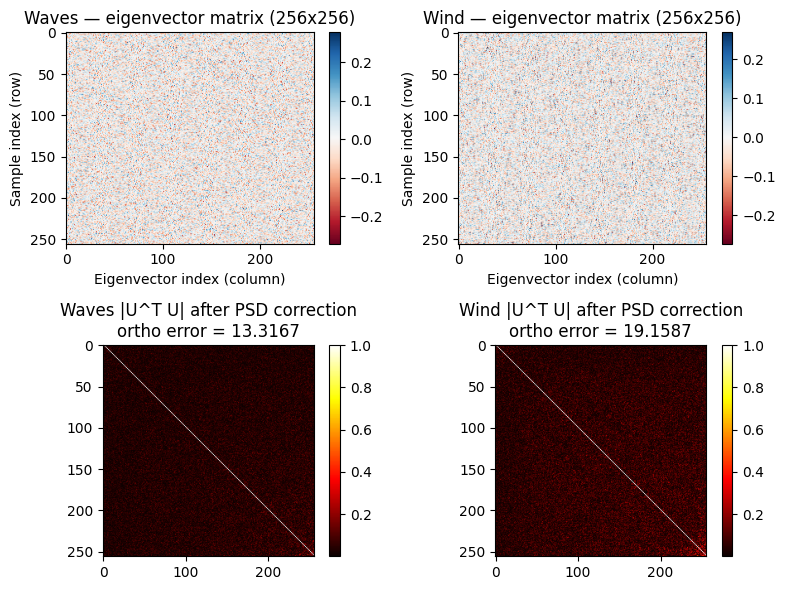


Inital dictionary and frames are ready.


In [ ]:
#=============================================================================================
# Dictionary Initialization
#=============================================================================================


def initialize(frames):
    # PCA
    frames = frames - frames.mean(axis=1, keepdims=True)  # (M, 1), frames.mean(axis=1, keepdims=True): average sound frame
    N = frames.shape[1]
    C = (frames @ frames.T) / N  # (M, M)


    eigenvalues, eigenvectors = np.linalg.eigh(C)  # eigh: numerically stable eigendecomposition for symmetric matrices
    order        = np.argsort(eigenvalues)[::-1]  # descending eigenvalue order
    eigenvectors = eigenvectors[:, order]          # (M, M) — columns are eigenvectors

    # Spectral correction
    frame_psds = np.abs(np.fft.fft(frames, axis=0)) ** 2 # (M, N)
    avg_frame_fft_amplitude = np.sqrt(frame_psds.mean(axis=1) + 1e-8)

    # For each eigenvector: keep phase, replace amplitude with avg amplitude
    corrected_cols = []
    for i in range(M):
        eigenvector    = eigenvectors[:, i]                # i-th eigenvector
        eigenvector_fft = np.fft.fft(eigenvector)         # complex spectrum
        phase    = np.angle(eigenvector_fft)               # extract phase
        corrected_col_fft = avg_frame_fft_amplitude * np.exp(1j * phase)  # replace amplitude, keep phase
        corrected_col   = np.fft.ifft(corrected_col_fft) # back to time domain
        corrected_col =  np.real(corrected_col)  # real part because we're dealing with audio signals and the cols aren't precisely orthogonal anyway

        # Normalize to unit L2 norm (column convention)
        corrected_col = corrected_col / (np.linalg.norm(corrected_col) + 1e-8)
        corrected_cols.append(corrected_col)

    # Stack corrected eigenvectors as columns -> (M, M)
    U_init = np.stack(corrected_cols, axis=1).astype(np.float32)

    ortho_error_after = np.linalg.norm(U_init.T @ U_init - np.eye(M))
    print(f"Orthogonality error after PSD correction: {ortho_error_after:.6f}")

    return U_init



# ── Run for waves and wind ─────────────────────────────────────────────────────
print("=" * 50)
print("Building WAVES block...")
U_waves_init = initialize(wave_frames)

print("\n" + "=" * 50)
print("Building WIND block...")
U_wind_init = initialize(wind_frames)

# ── Sanity plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, U, title in zip(axes[0], [U_waves_init, U_wind_init], ['Waves', 'Wind']):
    im = ax.imshow(U, cmap='RdBu', aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} — eigenvector matrix ({M}x{M})")
    ax.set_xlabel("Eigenvector index (column)")
    ax.set_ylabel("Sample index (row)")

for ax, U, title in zip(axes[1], [U_waves_init, U_wind_init], ['Waves', 'Wind']):
    UtU   = U.T @ U
    error = np.linalg.norm(UtU - np.eye(M))
    im    = ax.imshow(np.abs(UtU), cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} |U^T U| after PSD correction\northo error = {error:.4f}")

plt.tight_layout()
plt.show()

print("\nInital dictionary and frames are ready.")

In [ ]:
#=============================================================================================
# Dictionary Training
#=============================================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Hyperparameters ───────────────────────────────────────────────────────────
LAMBDA_PSD          = 1.0    # PSD matching loss weight
LAMBDA_MEL          = 1.0    # mel spectrogram loss weight
LAMBDA_ORTHO        = 2.0    # orthogonality weight

N_EPOCHS            = 1000    # training epochs
BATCH_SIZE          = 20     # codewords per step
LR     = 1e-4   # reduced from 3e-4
LR_MIN = 1e-6   # minimum LR at end of annealing

def compute_avg_psd_torch(frames):
    frame_psds = torch.fft.fft(frames, dim=0).abs() ** 2
    return frame_psds.mean(dim=1)  # (M,)

def compute_avg_mel_torch(frames, sr, n_fft, hop_length, n_mels): # torch version for learning

    # torchaudio expects (..., time)
    frames = frames.T # (M, N) -> (N, M)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    ).to(frames.device)

    mels = mel_transform(frames) # (N, M) -> (N, n_mels, n_time_bins)
    avg_mel = mels.mean(dim=0) # average over N frames

    return avg_mel

def train(encoder, frames_list):
    A_init = np.stack(encoder.A_list, axis = 0)  # (G, M, M)
    A = nn.Parameter(torch.as_tensor(A_init, dtype=torch.float32, device = device))
    frames_list = [torch.as_tensor(frames_list[g], dtype=torch.float32, device=device) for g in range(encoder.G)]
    # extract avg psd and mel because that's what we need. maybe that's what we need to turn into torch tensors

    avg_psd = []
    avg_mel = []
    for g in range(encoder.G):
        avg_psd.append(compute_avg_psd_torch(frames_list[g]))
        avg_mel.append(compute_avg_mel_torch(frames_list[g], SR, N_FFT, HOP_LENGTH, N_MELS))


    opt = torch.optim.Adam([A], lr = LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS, eta_min=LR_MIN)


    history = []
    checkpoints = []

    for epoch in range(N_EPOCHS):
        opt.zero_grad()

        B0 =int(np.floor(np.log2(encoder.G)))

        bits = []  # Initial list of bitstreams
        for g in range(encoder.G):
            bits_g = np.random.randint(0,2, size = (BATCH_SIZE, encoder.B))  # (BATCH_SIZE, B)
            bits_index = np.array(list(map(int, format(g, f"0{B0}b"))), dtype=int)  # map block index to corresponding bits
            # e.g. g = 5, B0 = 8 -> 00000101
            bits_g[:, :B0] = bits_index  #  for each block, all random bits are assigned the correct index bits
            bits.append(bits_g)  # (G, BATCH_SIZE, B)

        bits = np.stack(bits, axis=0) # (G, BATCH_SIZE, B), bitstreams


        c = []  # Initial list of codewords
        for g in range(encoder.G):
            # c is generated indirectly rather than straight from the encoder
            # because A needs to stay a learnable torch tensor the entire time.
            _, _, x_g = encoder.encode(bits[g])  # (BATCH_SIZE, M)
            x_g = torch.as_tensor(x_g, dtype=torch.float32, device=device)

            c_g = x_g @ A[g].T # (BATCH_SIZE, M) @ (M, M) = (BATCH_SIZE, M)  -> maybe we can do this differently with tensor reshaping
            # c_g = A[g] @ x_g isn't used here because of the BATCH_SIZE axis
            c.append(c_g)  # (G, BATCH_SIZE, M)

        c = torch.stack(c, dim=0) # (G, BATCH_SIZE, M),

        loss_psd, loss_mel, loss_ortho   = 0.0, 0.0, 0.0


        I = torch.eye(encoder.M, dtype=torch.float32, device=device)

        for g in range(encoder.G):

            c_g = c[g] # (BATCH_SIZE, M)

            c_g_psd = (torch.fft.fft(c_g, dim = -1).abs() ** 2).mean(dim=0)  # using batch averaged psd's has more stable and predictable results
            loss_psd += torch.mean ((torch.log(c_g_psd+ 1e-8)-torch.log(avg_psd[g]+ 1e-8)).abs() **2)
            #c_g_psd = torch.fft.fft(c_g, dim=-1).abs() ** 2
            #loss_psd += torch.mean((torch.log(c_g_psd + 1e-8) - torch.log(avg_psd[g] + 1e-8)) ** 2) # just in case

            c_g_mel = compute_avg_mel_torch(c_g.T, SR, N_FFT, HOP_LENGTH, N_MELS)
            loss_mel += torch.mean((torch.log(c_g_mel + 1e-8) - torch.log(avg_mel[g] + 1e-8)).abs() **2)


             # average squared orthogonality error per column, the encoder.M factor also makes the different losses more balanced
            gram = A[g].T @ A[g]
            loss_ortho += encoder.M*torch.mean(torch.abs((gram - I)) ** 2)

        loss = (LAMBDA_PSD * loss_psd + LAMBDA_MEL * loss_mel + LAMBDA_ORTHO * loss_ortho)
        loss.backward()  # backpropagation
        torch.nn.utils.clip_grad_norm_([A], max_norm=1.0) # prevents exploding gradients
        opt.step()
        scheduler.step()
        history.append({
            "epoch": epoch + 1,
            "loss": loss.item(),
            "covert":loss_psd.item()+loss_mel.item(),
            "psd": loss_psd.item(),
            "mel": loss_mel.item(),
            "ortho": loss_ortho.item(),
            "lr": scheduler.get_last_lr()[0]
        })

        checkpoints.append({"epoch": epoch + 1, "A": A.detach().cpu().numpy().copy()})

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(
                f"[ep {epoch+1:3d}/{N_EPOCHS}] "
                f"L={loss.item():.4e} | "
                f"PSD={loss_psd.item():.4e} | "
                f"MEL={loss_mel.item():.4e} | "
                f"ORTHO={loss_ortho.item():.4e}"
            )


    A_trained = A.detach().cpu().numpy()
    encoder.A_list = [A_trained[g].copy() for g in range(encoder.G)]

    return encoder, history, checkpoints






Using device: cpu


In [ ]:
encoder_init= BOSSEncoder(
    M=M, G=G, L=L,
    sparsity_levels=sparsity_levels,
    alphabets=alphabets,
    A_list=[U_waves_init, U_wind_init]
)

encoder_trained, history, checkpoints = train(encoder_init, [wave_frames,wind_frames])
U_waves_trained, U_wind_trained = encoder_trained.A_list[0], encoder_trained.A_list[1]

[ep   1/1000] L=6.2675e+00 | PSD=9.7916e-01 | MEL=1.0353e+00 | ORTHO=2.1265e+00
[ep  50/1000] L=5.0871e+00 | PSD=8.5311e-01 | MEL=9.0816e-01 | ORTHO=1.6629e+00
[ep 100/1000] L=4.1364e+00 | PSD=6.9640e-01 | MEL=7.3329e-01 | ORTHO=1.3534e+00
[ep 150/1000] L=3.5341e+00 | PSD=6.1523e-01 | MEL=6.5066e-01 | ORTHO=1.1341e+00
[ep 200/1000] L=3.0350e+00 | PSD=5.2793e-01 | MEL=5.4021e-01 | ORTHO=9.8341e-01
[ep 250/1000] L=2.6859e+00 | PSD=4.4962e-01 | MEL=4.8220e-01 | ORTHO=8.7704e-01
[ep 300/1000] L=2.4293e+00 | PSD=4.0363e-01 | MEL=4.2192e-01 | ORTHO=8.0185e-01
[ep 350/1000] L=2.2203e+00 | PSD=3.5622e-01 | MEL=3.6575e-01 | ORTHO=7.4914e-01
[ep 400/1000] L=2.0679e+00 | PSD=3.1111e-01 | MEL=3.3329e-01 | ORTHO=7.1176e-01
[ep 450/1000] L=1.9430e+00 | PSD=2.7633e-01 | MEL=2.9796e-01 | ORTHO=6.8437e-01
[ep 500/1000] L=1.8665e+00 | PSD=2.5924e-01 | MEL=2.7825e-01 | ORTHO=6.6450e-01
[ep 550/1000] L=1.8249e+00 | PSD=2.5630e-01 | MEL=2.6820e-01 | ORTHO=6.5019e-01
[ep 600/1000] L=1.7421e+00 | PSD=2.2679e

Saved trained matrices to /content/outputs/


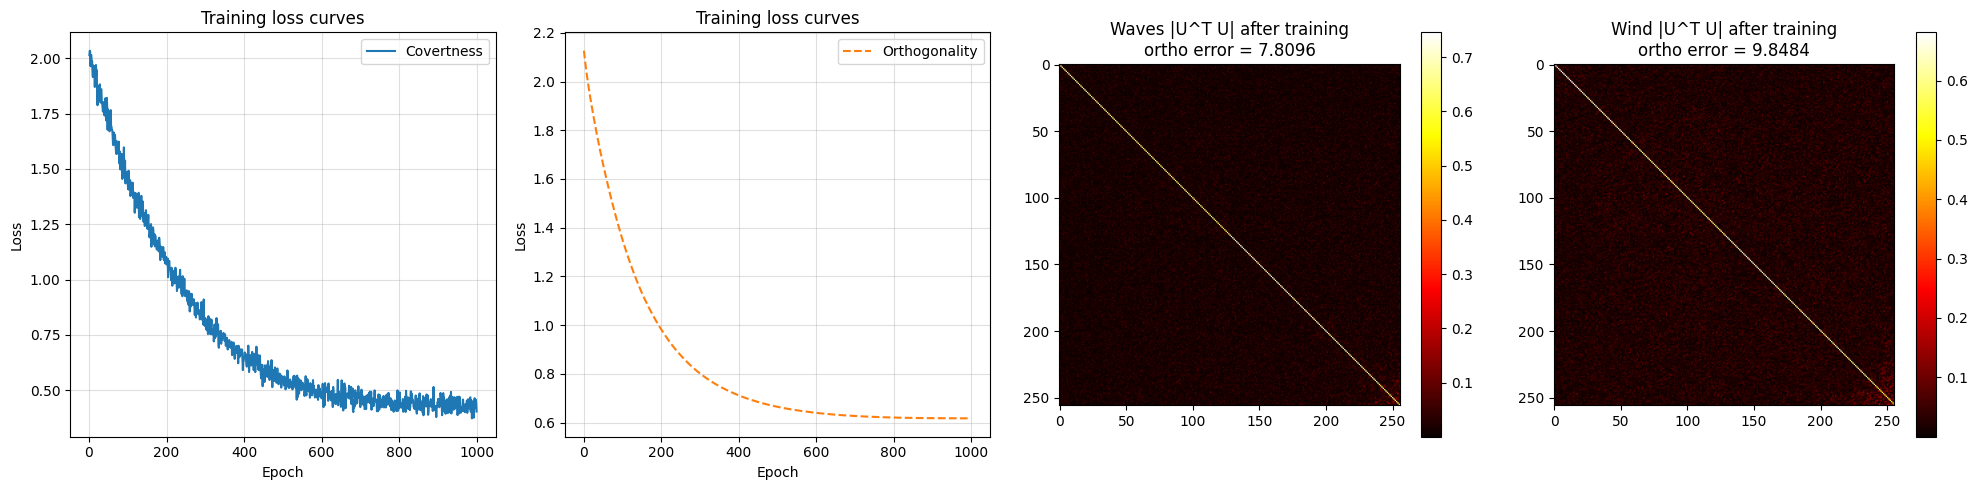

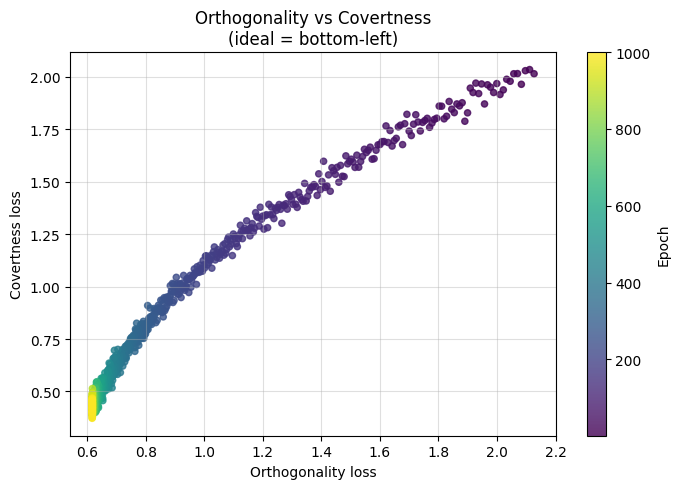

In [ ]:
# ── Save trained matrices ─────────────────────────────────────────────────────
os.makedirs("/content/outputs", exist_ok=True)
np.save("/content/outputs/U_waves_trained.npy", U_waves_trained)
np.save("/content/outputs/U_wind_trained.npy",  U_wind_trained)
print("Saved trained matrices to /content/outputs/")

# ── Plotting ──────────────────────────────────────────────────────────────────
epochs = [h['epoch']  for h in history]
covert = [h['covert'] for h in history]
ortho  = [h['ortho']  for h in history]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.plot(epochs, covert, label='Covertness', lw=1.5, color='tab:blue')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss curves')
ax.legend(); ax.grid(True, alpha=0.4)

ax = axes[1]
ax.plot(epochs, ortho,  label='Orthogonality', lw=1.5, color='tab:orange', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training loss curves')
ax.legend(); ax.grid(True, alpha=0.4)

for ax, U, title in zip(axes[2:],
                         [U_waves_trained, U_wind_trained],
                         ['Waves', 'Wind']):
    UtU   = U.T @ U
    error = np.linalg.norm(UtU - np.eye(M))
    im    = ax.imshow(np.abs(UtU), cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_title(f"{title} |U^T U| after training\northo error = {error:.4f}")

plt.tight_layout()
plt.show()

# Pareto scatter
plt.figure(figsize=(7, 5))
sc = plt.scatter(ortho, covert, c=epochs, cmap='viridis', s=20, alpha=0.8)
plt.colorbar(sc, label='Epoch')
plt.xlabel('Orthogonality loss')
plt.ylabel('Covertness loss')
plt.title('Orthogonality vs Covertness\n(ideal = bottom-left)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
#=============================================================================================
# Dictionary Post-Processing (QR-Decomposition)
#=============================================================================================
def qr_encoder(encoder):
    qr_list = []

    for g in range(encoder.G):
        U = encoder.A_list[g]
        Q, _ = np.linalg.qr(U.T)
        qr_list.append(Q.T.astype(np.float32))

    return BOSSEncoder(
        M=encoder.M,
        G=encoder.G,
        L=encoder.L,
        sparsity_levels=encoder.sparsity_levels,
        alphabets=encoder.alphabets,
        candidate_set_sizes=encoder.candidate_set_sizes,
        A_list=qr_list
    )

def qr_matrix(U_np): # do i need this
    Q, _ = np.linalg.qr(U_np.T)
    return Q.T.astype(np.float32)

encoder_qr = qr_encoder(encoder_trained)

U_waves_qr, U_wind_qr = encoder_qr.A_list[0], encoder_qr.A_list[1]


cross = np.linalg.norm(U_waves_trained.T @ U_wind_trained)
print(f"Inter-block cross correlation: {cross:.4f}")

cross_qr = np.linalg.norm(U_waves_qr.T @ U_wind_qr)
print(f"Inter-block cross correlation (QR): {cross_qr:.4f}")



Inter-block cross correlation: 9.7844
Inter-block cross correlation (QR): 16.0000


In [ ]:
# Normalized frequency axis — -pi to pi
omega = np.linspace(-np.pi, np.pi, M, endpoint=False)

# ── Listen to codewords + PSD plots ──────────────────────────────────────────
def listen_to_codewords(encoder, block_name, sr, avg_psd_ref, n_random=4):
    """
    Generate n_random codewords using the trained encoder, play each one,
    and show a PSD comparison plot for each.
    Block index is inferred from block_name: 'Waves' -> g=0, 'Wind' -> g=1.
    """
    print(f"\n{'='*50}")
    print(f"Listening to {block_name} codewords (sr={sr} Hz)")
    print(f"{'='*50}")

    playback_sr = 16000
    target      = int(M * playback_sr / SR)

    block_bit = 0 if block_name.lower() == 'waves' else 1
    B         = encoder.B
    B_0       = int(np.floor(np.log2(encoder.G)))

    upsampled_cws = []

    for i in range(n_random):
        # Build bit source
        block_bits  = np.array([block_bit] * B_0, dtype=np.float32)
        random_bits = np.random.randint(0, 2, size=B - B_0).astype(np.float32)
        bits        = np.concatenate([block_bits, random_bits])

        # Encode
        c, g, x_g = encoder.encode(bits)   # c: shape (M,)

        # PSD of this codeword — fftshift for -pi to pi
        psd_cw = np.fft.fftshift(np.abs(np.fft.fft(c)) ** 2)

        # Normalize both PSDs to compare shape not energy
        psd_cw_norm  = psd_cw  / (psd_cw.sum()  + 1e-8)
        psd_ref_norm = avg_psd_ref / (avg_psd_ref.sum() + 1e-8)

        # Plot
        plt.figure(figsize=(8, 3))
        plt.plot(omega, psd_ref_norm, label=f'{block_name} avg PSD (reference)',
                 color='tab:blue', lw=1.5, alpha=0.8)
        plt.plot(omega, psd_cw_norm,  label=f'Codeword {i+1} PSD',
                 color='tab:orange', lw=1.5, alpha=0.8)
        plt.xlabel('Normalized frequency (radians)')
        plt.ylabel('Normalized power')
        plt.title(f'{block_name} — Codeword {i+1}  '
                  f'(g={g}, non-zero: {np.where(x_g != 0)[0]})')
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

        # Upsample for playback
        c_t       = torch.tensor(c, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        upsampled = F.interpolate(c_t, size=target, mode='linear',
                                  align_corners=False).squeeze()
        audio     = upsampled / (upsampled.abs().max() + 1e-8)
        upsampled_cws.append(upsampled)

        print(f"  Codeword {i+1} (g={g}, non-zero indices: {np.where(x_g != 0)[0]}):")
        ipd.display(ipd.Audio(audio.numpy(), rate=playback_sr))

    # Concatenation
    concat_audio = torch.cat(upsampled_cws, dim=0)
    concat_audio = concat_audio / (concat_audio.abs().max() + 1e-8)
    print(f"\n  Concatenation of {n_random} codewords "
          f"({n_random} × {M/SR:.2f}s = {n_random * M/SR:.2f}s total):")
    ipd.display(ipd.Audio(concat_audio.numpy(), rate=playback_sr))


Listening to Waves codewords (sr=1024 Hz)


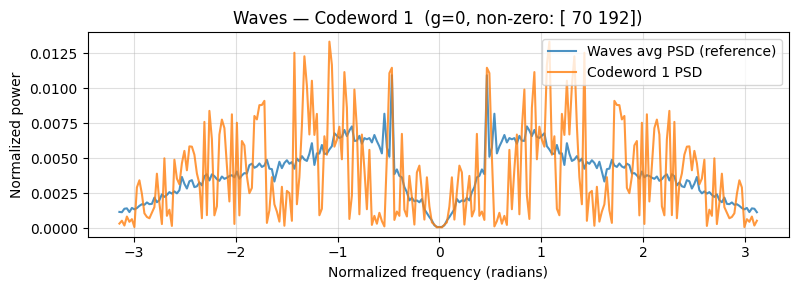

  Codeword 1 (g=0, non-zero indices: [ 70 192]):


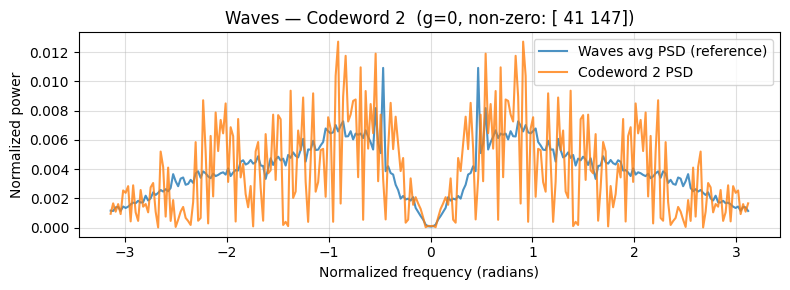

  Codeword 2 (g=0, non-zero indices: [ 41 147]):


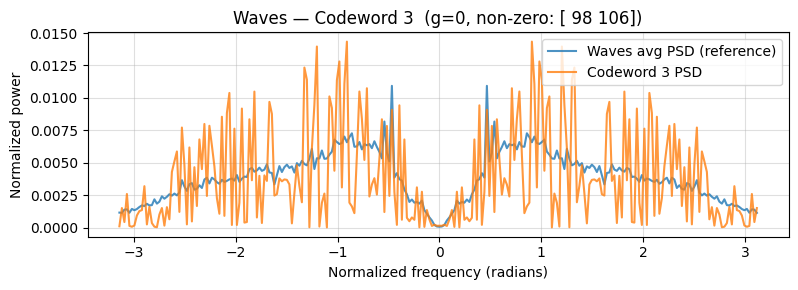

  Codeword 3 (g=0, non-zero indices: [ 98 106]):


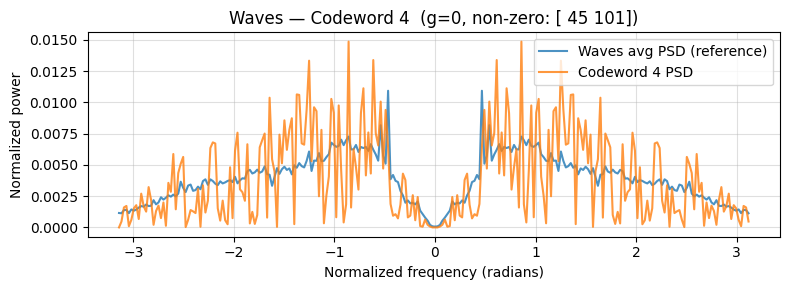

  Codeword 4 (g=0, non-zero indices: [ 45 101]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind codewords (sr=1024 Hz)


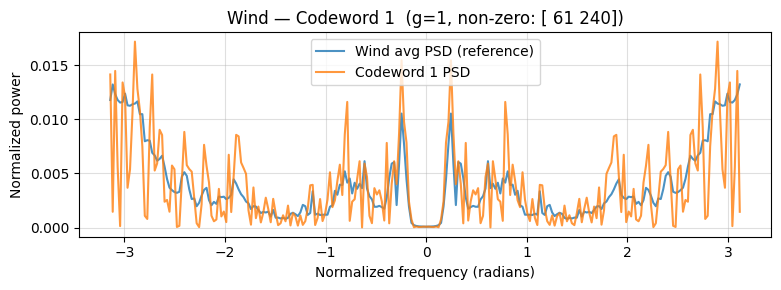

  Codeword 1 (g=1, non-zero indices: [ 61 240]):


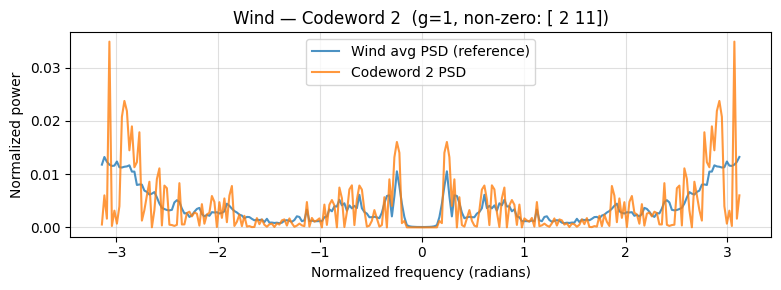

  Codeword 2 (g=1, non-zero indices: [ 2 11]):


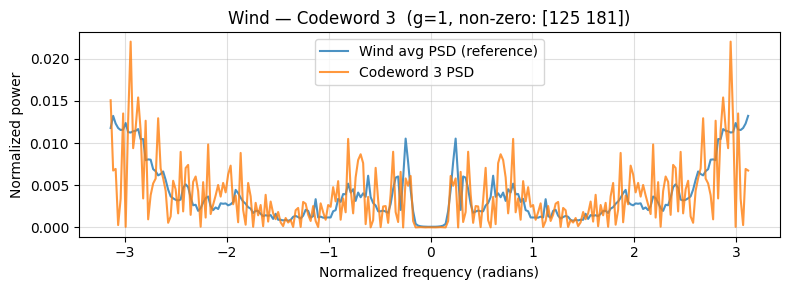

  Codeword 3 (g=1, non-zero indices: [125 181]):


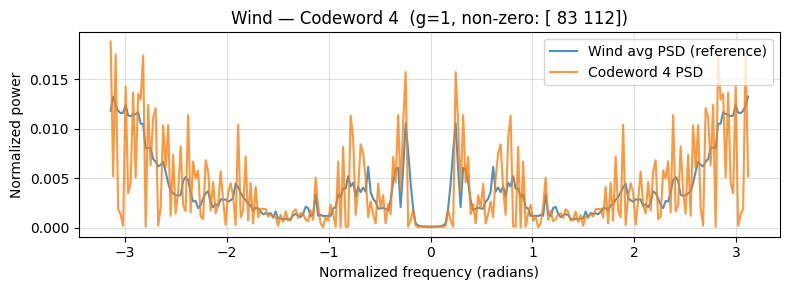

  Codeword 4 (g=1, non-zero indices: [ 83 112]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Waves [QR-fixed] codewords (sr=1024 Hz)


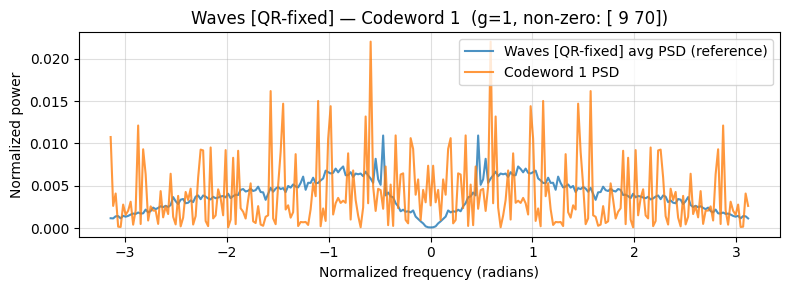

  Codeword 1 (g=1, non-zero indices: [ 9 70]):


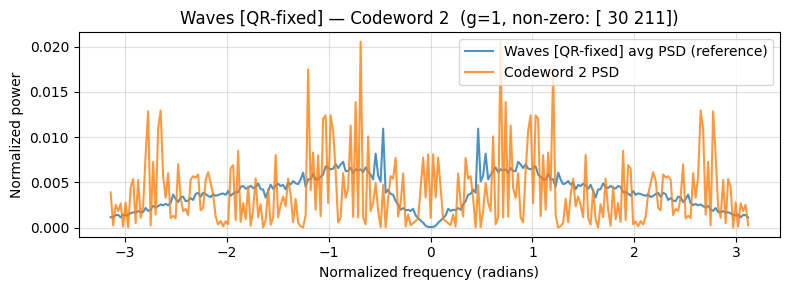

  Codeword 2 (g=1, non-zero indices: [ 30 211]):


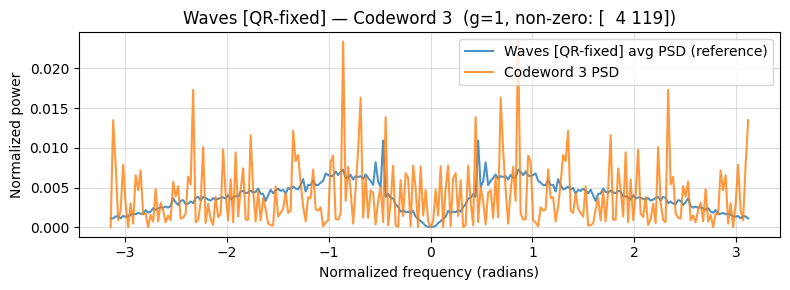

  Codeword 3 (g=1, non-zero indices: [  4 119]):


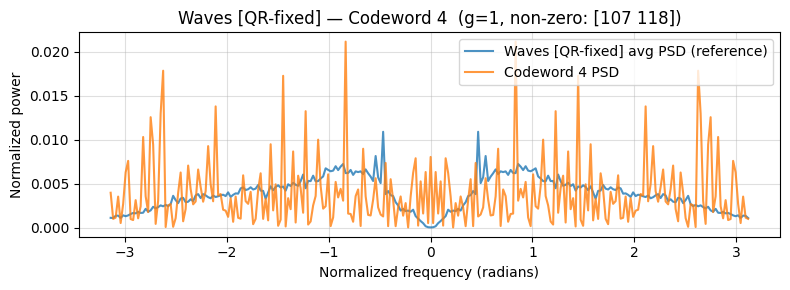

  Codeword 4 (g=1, non-zero indices: [107 118]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):



Listening to Wind  [QR-fixed] codewords (sr=1024 Hz)


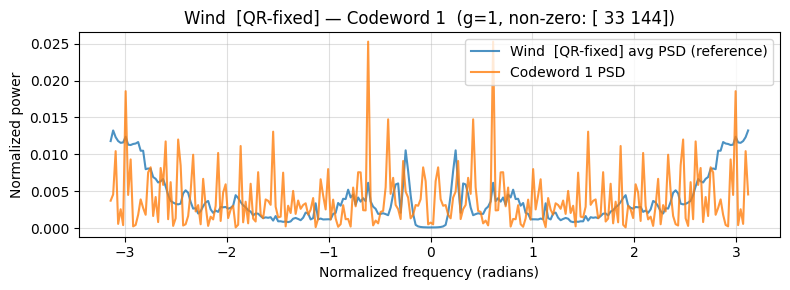

  Codeword 1 (g=1, non-zero indices: [ 33 144]):


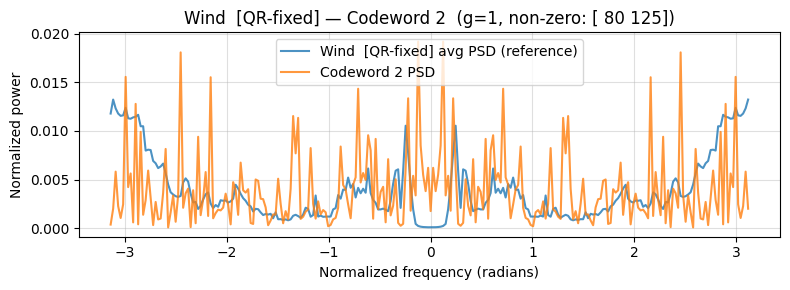

  Codeword 2 (g=1, non-zero indices: [ 80 125]):


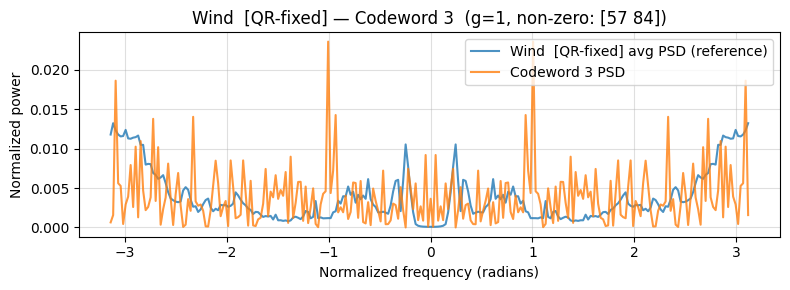

  Codeword 3 (g=1, non-zero indices: [57 84]):


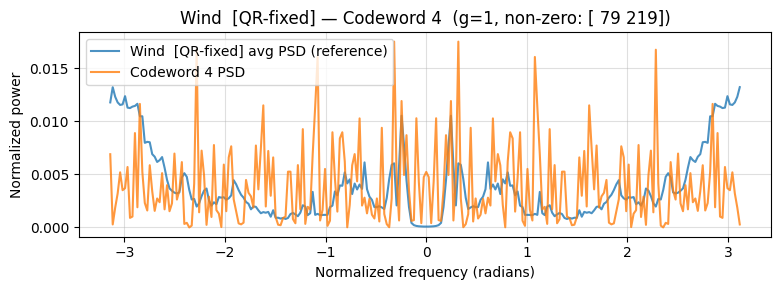

  Codeword 4 (g=1, non-zero indices: [ 79 219]):



  Concatenation of 4 codewords (4 × 0.25s = 1.00s total):


In [ ]:

# =============================================================================
# encoder_simplified_no_qr
# =============================================================================

encoder_simplified_no_qr = BOSSEncoder(
    M=M, G=G, L=L,
    sparsity_levels=sparsity_levels,
    alphabets=alphabets,
    A_list=[U_waves_trained, U_wind_trained]
)

listen_to_codewords(encoder_simplified_no_qr, "Waves", SR, avg_psd_waves)
listen_to_codewords(encoder_simplified_no_qr, "Wind",  SR, avg_psd_wind)

# =============================================================================
# encoder_simplified_qr
# =============================================================================
encoder_simplified_qr = qr_encoder(encoder_simplified_no_qr)

listen_to_codewords(encoder_simplified_qr,   "Waves [QR-fixed]", SR, avg_psd_waves)
listen_to_codewords(encoder_simplified_qr,   "Wind  [QR-fixed]", SR, avg_psd_wind)

# =============================================================================
# encoder_hadamard
# =============================================================================
encoder_hadamard = BOSSEncoder(
    M=M, G=G, L=L,
    sparsity_levels=sparsity_levels,
    alphabets=alphabets
)

In [ ]:
from google.colab import files

uploaded = files.upload()

#=============================================================================================
# Import original BOSS matrices from capstone project
#=============================================================================================
data = np.load("boss_capstone_matrices.npz")

A_stack = data["A"]  # shape (G, M, M)


print("Loaded:", A_stack.shape)

#=============================================================================================
# encoder_capstone_no_qr
#=============================================================================================
encoder_capstone_no_qr = BOSSEncoder(
    M=M, G=G, L=L, sparsity_levels=sparsity_levels, alphabets=alphabets,
    A_list=[A_stack[g].copy() for g in range(A_stack.shape[0])]
)

#=============================================================================================
# encoder_capstone_qr
#=============================================================================================

encoder_capstone_qr = qr_encoder(encoder_capstone_no_qr)


Saving boss_capstone_matrices.npz to boss_capstone_matrices.npz
Loaded: (2, 256, 256)


In [ ]:
#=============================================================================================
# BLER Simulations
#=============================================================================================
def simulate_bler_ca_boss(encoder, ebno_db_range, polynomial, B_info,
                           batch_size=250, num_target_block_errors=250, max_mc_iter=200):
    blers = []
    degree = len(polynomial) - 1

    for ebno_db in ebno_db_range:
        rate = B_info / encoder.M
        Es     = encoder.K / encoder.M
        sigma2 = Es / (2 * rate * 10 ** (ebno_db / 10))

        decoder = BOSSDecoderAWGN(encoder, sigma2_v=sigma2, list_size=4, crc_poly=polynomial)

        block_errors = 0
        total_blocks = 0

        for _ in range(max_mc_iter):
            bits_batch = np.random.randint(0, 2, (batch_size, B_info)) # bit source

            encoded = [ca_boss_encode(bits_batch[i], encoder, polynomial) for i in range(batch_size)]
            c_batch = np.stack([x[0] for x in encoded])

            noise_batch = np.random.normal( # AWGN
                0, np.sqrt(sigma2), c_batch.shape
            ).astype(np.float32)
            y_batch = c_batch + noise_batch

            bits_hat_batch, _, _ = decoder.decode(y_batch)

            for i in range(batch_size):
                valid = crc_check(bits_hat_batch[i], polynomial)
                bits_hat = bits_hat_batch[i][:-degree]
                if not valid or not np.array_equal(bits_batch[i], bits_hat):
                    block_errors += 1 # erroneous blocks
                total_blocks += 1

            if block_errors >= num_target_block_errors:
                break

        bler = block_errors / total_blocks
        blers.append(bler)
        print(f"[CA-BOSS] Eb/N0 = {ebno_db:.1f} dB  |  BLER = {bler:.4f}  ({block_errors}/{total_blocks})")

    return blers # BLER wrt to each Eb/N0



print("\nSimulating CA-BOSS (encoder_simplified_no_qr)")
blers_simplified_no_qr = simulate_bler_ca_boss(
    encoder_simplified_no_qr, ebno_db_range, crc_poly, B_info,
    batch_size=250, num_target_block_errors=250, max_mc_iter=200
)
print("\nSimulating CA-BOSS (encoder_simplified_qr)")
blers_simplified_qr = simulate_bler_ca_boss(
    encoder_simplified_qr, ebno_db_range, crc_poly, B_info,
    batch_size=250, num_target_block_errors=250, max_mc_iter=200
)
print("\nSimulating CA-BOSS (encoder_capstone_no_qr)")
blers_capstone_no_qr = simulate_bler_ca_boss(
    encoder_capstone_no_qr, ebno_db_range, crc_poly, B_info,
    batch_size=250, num_target_block_errors=250, max_mc_iter=200
)
print("\nSimulating CA-BOSS (encoder_capstone_qr)")
blers_capstone_qr = simulate_bler_ca_boss(
    encoder_capstone_qr, ebno_db_range, crc_poly, B_info,
    batch_size=250, num_target_block_errors=250, max_mc_iter=200
)
print("\nSimulating CA-BOSS (encoder_hadamard)")
blers_hadamard = simulate_bler_ca_boss(
    encoder_hadamard, ebno_db_range, crc_poly, B_info,
    batch_size=250, num_target_block_errors=250, max_mc_iter=200
)





Simulating CA-BOSS (encoder_simplified_no_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  BLER = 0.7180  (359/500)
[CA-BOSS] Eb/N0 = 0.0 dB  |  BLER = 0.6260  (313/500)
[CA-BOSS] Eb/N0 = 1.0 dB  |  BLER = 0.4560  (342/750)
[CA-BOSS] Eb/N0 = 2.0 dB  |  BLER = 0.2620  (262/1000)
[CA-BOSS] Eb/N0 = 3.0 dB  |  BLER = 0.1255  (251/2000)
[CA-BOSS] Eb/N0 = 4.0 dB  |  BLER = 0.0445  (256/5750)
[CA-BOSS] Eb/N0 = 5.0 dB  |  BLER = 0.0107  (252/23500)

Simulating CA-BOSS (encoder_simplified_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  BLER = 0.4133  (310/750)
[CA-BOSS] Eb/N0 = 0.0 dB  |  BLER = 0.2670  (267/1000)
[CA-BOSS] Eb/N0 = 1.0 dB  |  BLER = 0.1124  (281/2500)
[CA-BOSS] Eb/N0 = 2.0 dB  |  BLER = 0.0411  (257/6250)
[CA-BOSS] Eb/N0 = 3.0 dB  |  BLER = 0.0092  (252/27500)
[CA-BOSS] Eb/N0 = 4.0 dB  |  BLER = 0.0015  (74/50000)
[CA-BOSS] Eb/N0 = 5.0 dB  |  BLER = 0.0001  (6/50000)

Simulating CA-BOSS (encoder_capstone_no_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  BLER = 0.4973  (373/750)
[CA-BOSS] Eb/N0 = 0.0 dB  |  BLER = 0.28

In [ ]:
#=============================================================================================
# Probability of detection Simulations
#=============================================================================================
def normalized_psd_l2_distance(psd_1, psd_2, eps=1e-8):
    """
    Compute the L2 distance between two normalized PSDs.
    """
    # normalizing psd's because waveform shape matters more than absolute energy.
    # waves and wind have a wide varity of noises
    psd_1_norm = psd_1 / (psd_1.sum() + eps)
    psd_2_norm = psd_2 / (psd_2.sum() + eps)

    return np.linalg.norm(psd_1_norm - psd_2_norm)


def frames_to_threshold(frames, avg_psd_ref, p_fa=0.01):
    """
    frames: shape (M, N), each column is one ambient frame
    """

    distances = []

    for i in range(frames.shape[1]):  # over all N columns
        frame = frames[:, i]  # each column

        psd = np.abs(np.fft.fft(frame)) ** 2
        psd = np.fft.fftshift(psd)

        dist = normalized_psd_l2_distance(psd, avg_psd_ref)
        distances.append(dist)

    distances = np.asarray(distances)  # convert list to numpy array

    threshold = np.quantile(distances, 1 - p_fa)  # p_fa = probability of false alarm

    return threshold


threshold_waves = frames_to_threshold(wave_frames, avg_psd_waves, p_fa=0.05)
threshold_wind = frames_to_threshold(wind_frames, avg_psd_wind, p_fa=0.05)


def simulate_pd_ca_boss(encoder, ebno_db_range, polynomial, B_info,
                         avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
                           batch_size=250, max_mc_iter=400):
    pds = []

    psd_ref_waves = avg_psd_waves / (avg_psd_waves.sum() + 1e-8)
    psd_ref_wind  = avg_psd_wind / (avg_psd_wind.sum() + 1e-8)
    psd_refs = np.stack([psd_ref_waves, psd_ref_wind], axis=0)

    for ebno_db in ebno_db_range:
        rate = B_info / encoder.M
        Es     = encoder.K / encoder.M
        sigma2 = Es / (2 * rate * 10 ** (ebno_db / 10))

        detected_blocks = 0
        total_blocks = 0

        for _ in range(max_mc_iter):
            bits_batch = np.random.randint(0, 2, (batch_size, B_info)) # bit source

            encoded = [ca_boss_encode(bits_batch[i], encoder, polynomial) for i in range(batch_size)]
            c_batch = np.stack([x[0] for x in encoded])
            g_batch = np.array([x[1] for x in encoded])

            noise_batch = np.random.normal( # AWGN
                0, np.sqrt(sigma2), c_batch.shape
            ).astype(np.float32)
            y_batch = c_batch + noise_batch

            psd_batch = np.abs(np.fft.fft(y_batch, axis=1)) ** 2
            psd_batch = np.fft.fftshift(psd_batch, axes=1)
            psd_batch_norm = psd_batch / (psd_batch.sum(axis=1, keepdims=True) + 1e-8)

            psd_ref_batch = psd_refs[g_batch]

            thresholds = np.where(g_batch == 0, threshold_waves, threshold_wind)

            dist = np.sqrt(np.sum((psd_batch_norm - psd_ref_batch) ** 2, axis=1))
            detected_blocks += int(np.sum(dist > thresholds))
            total_blocks += batch_size

        pd = detected_blocks / total_blocks
        pds.append(pd)
        print(f"[CA-BOSS] Eb/N0 = {ebno_db:.1f} dB  |  PD = {pd:.4f}  ({detected_blocks}/{total_blocks})")

    return pds # pd wrt to each Eb/N0



print("\nSimulating CA-BOSS (encoder_simplified_no_qr)")
pds_simplified_no_qr = simulate_pd_ca_boss(
    encoder_simplified_no_qr, ebno_db_range, crc_poly, B_info,
    avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
    batch_size=250, max_mc_iter=400
)

print("\nSimulating CA-BOSS (encoder_simplified_qr)")
pds_simplified_qr = simulate_pd_ca_boss(
    encoder_simplified_qr, ebno_db_range, crc_poly, B_info,
    avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
    batch_size=250, max_mc_iter=400
)

print("\nSimulating CA-BOSS (encoder_capstone_no_qr)")
pds_capstone_no_qr = simulate_pd_ca_boss(
    encoder_capstone_no_qr, ebno_db_range, crc_poly, B_info,
    avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
    batch_size=250, max_mc_iter=400
)

print("\nSimulating CA-BOSS (encoder_capstone_qr)")
pds_capstone_qr = simulate_pd_ca_boss(
    encoder_capstone_qr, ebno_db_range, crc_poly, B_info,
    avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
    batch_size=250, max_mc_iter=400
)

print("\nSimulating CA-BOSS (encoder_hadamard)")
pds_hadamard = simulate_pd_ca_boss(
    encoder_hadamard, ebno_db_range, crc_poly, B_info,
    avg_psd_waves, avg_psd_wind, threshold_waves, threshold_wind,
    batch_size=250, max_mc_iter=400
)




Simulating CA-BOSS (encoder_simplified_no_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  PD = 0.0009  (88/100000)
[CA-BOSS] Eb/N0 = 0.0 dB  |  PD = 0.0010  (101/100000)
[CA-BOSS] Eb/N0 = 1.0 dB  |  PD = 0.0008  (84/100000)
[CA-BOSS] Eb/N0 = 2.0 dB  |  PD = 0.0006  (59/100000)
[CA-BOSS] Eb/N0 = 3.0 dB  |  PD = 0.0005  (53/100000)
[CA-BOSS] Eb/N0 = 4.0 dB  |  PD = 0.0006  (56/100000)
[CA-BOSS] Eb/N0 = 5.0 dB  |  PD = 0.0003  (33/100000)

Simulating CA-BOSS (encoder_simplified_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  PD = 0.0012  (119/100000)
[CA-BOSS] Eb/N0 = 0.0 dB  |  PD = 0.0016  (160/100000)
[CA-BOSS] Eb/N0 = 1.0 dB  |  PD = 0.0013  (131/100000)
[CA-BOSS] Eb/N0 = 2.0 dB  |  PD = 0.0015  (148/100000)
[CA-BOSS] Eb/N0 = 3.0 dB  |  PD = 0.0013  (131/100000)
[CA-BOSS] Eb/N0 = 4.0 dB  |  PD = 0.0015  (152/100000)
[CA-BOSS] Eb/N0 = 5.0 dB  |  PD = 0.0014  (136/100000)

Simulating CA-BOSS (encoder_capstone_no_qr)
[CA-BOSS] Eb/N0 = -1.0 dB  |  PD = 0.0008  (77/100000)
[CA-BOSS] Eb/N0 = 0.0 dB  |  PD = 0.0007  (

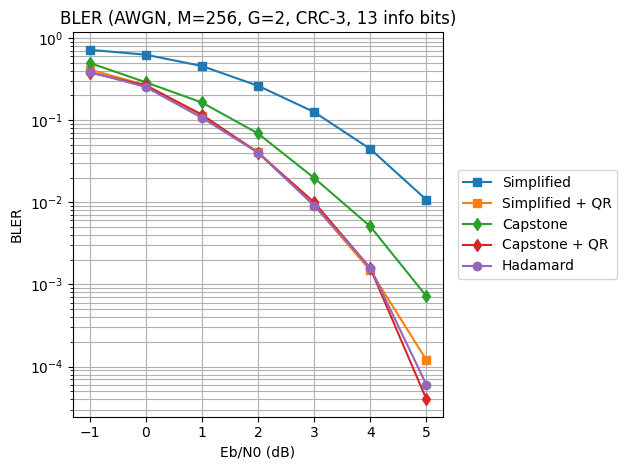

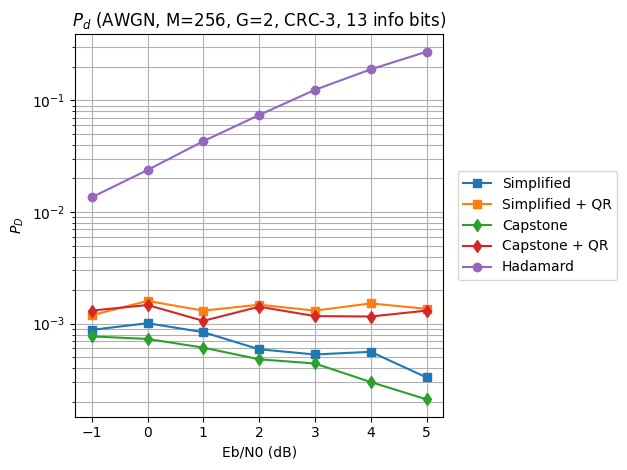

In [ ]:
plt.figure()

plt.semilogy(ebno_db_range, blers_simplified_no_qr, marker='s', label='Simplified')
plt.semilogy(ebno_db_range, blers_simplified_qr, marker='s', label='Simplified + QR')
plt.semilogy(ebno_db_range, blers_capstone_no_qr, marker='d', label='Capstone')
plt.semilogy(ebno_db_range, blers_capstone_qr, marker='d', label='Capstone + QR')
plt.semilogy(ebno_db_range, blers_hadamard, marker='o', label='Hadamard')

plt.xlabel('Eb/N0 (dB)')
plt.ylabel('BLER')
plt.grid(True, which='both')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.title(f'BLER (AWGN, M={M}, G={G}, CRC-{crc_degree}, {B_info} info bits)')
plt.tight_layout()
plt.show()


plt.figure()

plt.semilogy(ebno_db_range, pds_simplified_no_qr, marker='s', label='Simplified')
plt.semilogy(ebno_db_range, pds_simplified_qr, marker='s', label='Simplified + QR')
plt.semilogy(ebno_db_range, pds_capstone_no_qr, marker='d', label='Capstone')
plt.semilogy(ebno_db_range, pds_capstone_qr, marker='d', label='Capstone + QR')
plt.semilogy(ebno_db_range, pds_hadamard, marker='o', label='Hadamard')

plt.xlabel('Eb/N0 (dB)')
plt.ylabel('$P_D$')
plt.grid(True, which='both')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.title(f'$P_d$ (AWGN, M={M}, G={G}, CRC-{crc_degree}, {B_info} info bits)')
plt.tight_layout()
plt.show()